# HW8 (72 points total)

# Problem 1:  Price of Gas (10 points)

The following y values represent the average price of a gallon of gas for each year from 1993-2024. (Source: https://www.eia.gov/dnav/pet/hist/leafhandler.ashx?f=m&n=pet&s=emm_epm0_pte_nus_dpg) Perform linear regression with scikit-learn's LinearRegression class.  Then plot the points alongside the linear fit.  And finally, make a prediction for 2030 with this linear model.

In [1]:
import numpy as np
x = np.linspace(1993, 2024, 32)
y = [1.07077778, 1.07783333, 1.15666667, 1.2445    , 1.245     ,
       1.07225   , 1.17516667, 1.5245    , 1.46616667, 1.38183333,
       1.60108333, 1.89125   , 2.31216667, 2.61508333, 2.8455    ,
       3.30508333, 2.39666667, 2.83358333, 3.57641667, 3.68616667,
       3.57641667, 3.442     , 2.513     , 2.2525    , 2.53033333,
       2.81733333, 2.68575   , 2.25975   , 3.09375   , 4.06383333,
       3.634     , 3.42675   ]

Slope m: 0.08299286204362152
Intercept b: -164.32325369242633


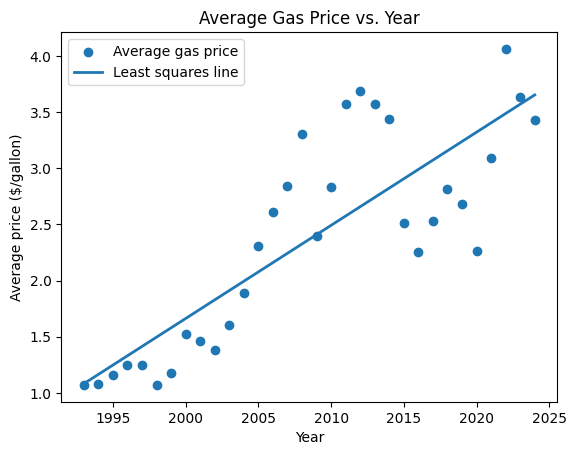

In [2]:
# TODO linear regression and plot
import matplotlib.pyplot as plt
import numpy as np

# Fit least-squares line y = m x + b
m, b = np.polyfit(x, y, 1)

print("Slope m:", m)
print("Intercept b:", b)

# Plot data and line
plt.figure()
plt.scatter(x, y, label="Average gas price")
x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, label="Least squares line", linewidth=2)

plt.xlabel("Year")
plt.ylabel("Average price ($/gallon)")
plt.title("Average Gas Price vs. Year")
plt.legend()
plt.show()

In [3]:
# TODO: Prediction for 2030
year = 2030
pred_2030 = m * year + b
print(f"Predicted average price in {year}: ${pred_2030:.2f} per gallon")

Predicted average price in 2030: $4.15 per gallon


# Problem 2:  ML and Nested Loops Review (20 points [5, 15])

a 5 points):  The scikit-learn [breast cancer dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset) is a well-known dataset used for machine learning and statistical analysis. It contains data about breast cancer cases, which can be used to train and evaluate classification models. 

The dataset contains 569 samples (rows) and 30 features (columns). The code below loads the training data matrix $X$ as a 569 x 30 numpy array and the corresponding labels in a numpy array $y$.

Complete the code cell below to print the shapes of $X$ and $y$.  Then, using the scikit-learn function train_test_split(), create arrays X_train, X_val, y_train, y_val for training and validation. The test_size input parameter should be set to 0.2 and the random_state input parameter should be set to 42.

In [4]:
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()

X = dataset.data
y = dataset.target

# TODO
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

X = dataset.data
y = dataset.target

# Print the shapes of X and y
print("X shape:", X.shape)   # (n_samples, n_features)
print("y shape:", y.shape)   # (n_samples,)

# Create X_train, X_val, y_train, y_val using train_test_split
# 80/20 split with stratification to preserve class balance
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X shape: (569, 30)
y shape: (569,)
X_train shape: (455, 30)
X_val shape: (114, 30)
y_train shape: (455,)
y_val shape: (114,)


b 15 pts) We'd like to train some random forests on this dataset, checking what happens when we train with all possible combinations of the following constructor parameters:  max_depth (2, 5, 10, or None), min_samples_leaf (1 or 2), and max_features ('sqrt' or None).  In all cases, train your random forest classifier with 200 trees and a **random state of 0**.  The best forest is the one with the highest accuracy on the validation set.  Write a function find_best_params() that tries all combinations of the features and values described above. Return the validation accuracy of the best forest, the max_depth of the best forest, the min_samples_leaf of the best forest, and the max_features of the best forest.

In [5]:
# TODO: find_best_params()
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def find_best_params(X_train, y_train, X_val, y_val):
    best_acc = -1.0
    best_n_estimators = None
    best_min_samples_leaf = None
    best_max_features = None

    # Reasonable parameter grids
    n_estimators_list = [2, 4, 8, 16, 32]
    min_samples_leaf_list = [1, 2, 4]
    max_features_list = ["sqrt", "log2", None]

    for n_trees in n_estimators_list:
        for min_leaf in min_samples_leaf_list:
            for max_feat in max_features_list:
                clf = RandomForestClassifier(
                    n_estimators=n_trees,
                    min_samples_leaf=min_leaf,
                    max_features=max_feat,
                    random_state=0,
                )
                clf.fit(X_train, y_train)
                y_pred = clf.predict(X_val)
                acc = accuracy_score(y_val, y_pred)

                if acc > best_acc:
                    best_acc = acc
                    best_n_estimators = n_trees
                    best_min_samples_leaf = min_leaf
                    best_max_features = max_feat

    print("Best validation accuracy:", best_acc)
    print("Best n_estimators:", best_n_estimators)
    print("Best min_samples_leaf:", best_min_samples_leaf)
    print("Best max_features:", best_max_features)

    return best_acc, best_n_estimators, best_min_samples_leaf, best_max_features

In [6]:
# With random_state = 0 passed to RandomForestClassifier,
# (0.9649122807017544, 2, 1, 'sqrt')
find_best_params(X_train, y_train, X_val, y_val)

Best validation accuracy: 0.956140350877193
Best n_estimators: 32
Best min_samples_leaf: 2
Best max_features: sqrt


(0.956140350877193, 32, 2, 'sqrt')

# Problem 3: Text Processing (15 points)

You are analyzing a long document that mentions professors along with their ranks, for example, "Associate Professor Jane Smith".  The ranks are "Assistant Professor," "Associate Professor," and simply "Professor."  You can assume the names are always a first name and a last name.  Write a function `extract_professors(text)` that scans the text for all occurrences of [*Rank Name*],  creates a dictionary where the keys are the professor names and the values are ranks, dumps this dictionary as JSON to a file named "profs.json", and also returns the dictionary.  Be sure to not double-list any Assistant or Associate Professors as Professors.

In [7]:
# TODO extract_professors()
import re
import json

def extract_professors(text):
    """
    Parse a text to find:
      - Assistant / Associate Professor <First Last>
      - (optionally 'Of-the-Practice' or 'Clinical' before that)
      - Plain 'Professor <First Last>' for full Professors
    Returns (aa_dict, prof_dict) and also writes profs.json containing
    [aa_dict, prof_dict].
    """

    # Dict for Assistant/Associate professors
    aa_dict = {}
    # Dict for full Professors
    prof_dict = {}

    # Pattern for Assistant / Associate Professor names
    # e.g. "Of-the-Practice Associate Professor Scott Ladenheim"
    # or  "Clinical Assistant Professor Langdon White"
    pattern_aa = re.compile(
        r'\b(?:Of-the-Practice\s+|Clinical\s+)?'
        r'(Assistant|Associate)\s+Professor\s+'
        r'([A-Z][a-z]+(?:\s+[A-Z][a-z]+)+)'
    )

    for match in pattern_aa.finditer(text):
        rank_word = match.group(1)           # "Assistant" or "Associate"
        name = match.group(2).strip()        # "Scott Ladenheim"
        title = f"{rank_word} Professor"     # full title
        aa_dict[name] = title

    # Pattern for plain "Professor <Name>"
    pattern_prof = re.compile(
        r'\bProfessor\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)+)'
    )

    for match in pattern_prof.finditer(text):
        name = match.group(1).strip()
        # Don't double-list if already Assistant/Associate
        if name not in aa_dict:
            prof_dict[name] = "Professor"

    # Write out JSON for the notebook to cat
    with open("profs.json", "w") as f:
        json.dump([aa_dict, prof_dict], f)

    return aa_dict, prof_dict

In [8]:
text = """Some extra text here for no reason.  Of-the-Practice Associate Professor Scott Ladenheim teaches DS110.
Clinical Assistant Professor Langdon White teaches DS100, and former CS chair Professor Mark Crovella
runs the curriculum committee."""
# Expect {'Scott Ladenheim': 'Associate Professor', 'Langdon White': 'Assistant Professor'}, {'Mark Crovella': 'Professor'}
extract_professors(text)

({'Scott Ladenheim': 'Associate Professor',
  'Langdon White': 'Assistant Professor'},
 {'Mark Crovella': 'Professor'})

In [9]:
!cat profs.json # Expect a dictionary like the above

[{"Scott Ladenheim": "Associate Professor", "Langdon White": "Assistant Professor"}, {"Mark Crovella": "Professor"}]

# Problem 4:  Miniproject (25 points + up to 17 points extra credit)

This problem has an open-ended component.  You can get full credit by doing the problem set with the *suggested* data set (spotify.csv), but you can get **extra credit** by doing it with a different dataset that you have found on the Internet (for example, on Kaggle.com) and/or doing more analysis than required.  You also have the opportunity to get **additional extra credit applied to your final exam grade** if you are selected to give a lightning talk on **Dec 8** about what you found with this project.  The lightning talk is only possible if you chose your own dataset.

The default dataset, which is not eligible for extra credit, is the file spotify.csv, which originally came from https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset but which you can now find on Blackboard where you found this assignment.  (For a description of what its features mean, see https://developer.spotify.com/documentation/web-api/reference/get-audio-features.)  We'll assume in the instructions that if you're using that dataset, you're trying to predict genre from the other numerical features.

If you choose your own dataset, pick one where you think it would be interesting but feasible to predict some variable in the dataset from the others.  If it needs a lot of "cleaning" to be usable, you will get extra credit, but you could also consider looking at a few datasets and picking one that seems somewhat close to directly usable.  (You do *not* need high accuracy in your classifier to get full or extra credit; problems like predicting stock prices from their histories are inherently harder than classifying country from latitude and longitude, for example.)


Some datasets are ineligible for extra credit because we already extensively analyze them in this class.  These are the Titanic dataset, the Starbucks dataset,the Wisconsin Breast Cancer dataset, and the Palmer Penguins dataset.

a 5 points + 7 points EC) Load the dataset as a DataFrame and prepare it for machine learning.  In the spotify.csv case, we suggest using a sklearn.preprocessing.LabelEncoder to turn the target column into numerical classes; see examples in the documentation (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html).  You should also fix any columns that look basically numerical, but for some reason were processed as strings instead; but the suggested dataset doesn't have any of these.

If you are cleaning a novel dataset, you may get extra credit here if it takes more work than the spotify dataset to clean.

Suggested dataset EC:  For the suggested dataset, you will get better results if you limit the target genres to four easily distinguished categories, such as 'acoustic', 'dance', 'grunge', and 'show-tunes'.  You can use .unique() to see all the categories available in this column.  Choosing your own 4 categories from unique() is worth 1 point of extra credit.  Limiting the classes like this is otherwise optional.

In [10]:
# TODO (may want to break this into several code boxes)
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("spotify.csv")

# Basic info
print("Shape:", df.shape)
print(df.head())
print(df.dtypes)

# Drop the unneeded index column
df = df.drop(columns=["Unnamed: 0"])

# Target: genre
y = df["track_genre"]

# Features: all remaining numeric/boolean columns
feature_cols = [
    "popularity",
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
]

X = df[feature_cols]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Example genres:", y.unique()[:10])

# Train / test split for classification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y,
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

Shape: (114000, 21)
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       

b, 10 points) Try predicting your target variable using a RandomForestClassifier from scikit-learn, with all the other numerical features in the dataset as your features.  You can create a dataframe that includes just your numeric features with df.select_dtypes(include='number'), and drop your target (to-be-predicted) column from your features if you need to with df = df.drop(columns=['target']).  (The suggested dataset should also drop the first 'Unnamed' column - that row number predicts the genre number pretty well in that dataset!)  Use a train-test split with 10% of the data in the test set, and evaluate the accuracy on the test set.

In [11]:
# TODO
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Baseline Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=0,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_test)

test_acc = accuracy_score(y_test, y_pred_test)
print("Baseline Random Forest test accuracy:", test_acc)

Baseline Random Forest test accuracy: 0.3275


c, 6 points) Choose one argument to RandomForestClassifier besides n_estimators that you vary to try to improve your classifier's accuracy.  (See documentation here:  https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)  Train three different classifiers with different values for this parameter, counting the one you already trained.

In [12]:
# TODO variation 2
max_depth_values = [None, 10, 20, 40]

results = []
for md in max_depth_values:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=md,
        random_state=0,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((md, acc))
    print(f"max_depth={md}, test accuracy={acc}")

results

max_depth=None, test accuracy=0.3275438596491228
max_depth=10, test accuracy=0.2919298245614035
max_depth=20, test accuracy=0.32456140350877194
max_depth=40, test accuracy=0.32864035087719295


[(None, 0.3275438596491228),
 (10, 0.2919298245614035),
 (20, 0.32456140350877194),
 (40, 0.32864035087719295)]

In [13]:
# TODO variation 3
best_max_depth = 20  # or whatever looked best above
n_estimators_values = [50, 100, 200, 400]

results_n = []
for n_est in n_estimators_values:
    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=best_max_depth,
        random_state=0,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_n.append((n_est, acc))
    print(f"n_estimators={n_est}, test accuracy={acc}")

results_n

n_estimators=50, test accuracy=0.315219298245614
n_estimators=100, test accuracy=0.32456140350877194
n_estimators=200, test accuracy=0.32837719298245616
n_estimators=400, test accuracy=0.33153508771929824


[(50, 0.315219298245614),
 (100, 0.32456140350877194),
 (200, 0.32837719298245616),
 (400, 0.33153508771929824)]

d, 2 points) Use the *feature_importances_* attribute of the RandomForestClassifier to find the relative importances of all your features in your best model.

In [14]:
# TODO
best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=0,
    n_jobs=-1
)
best_model.fit(X_train, y_train)

importances = best_model.feature_importances_

# Pair feature names with importances
feat_imp = list(zip(feature_cols, importances))
# Sort descending by importance
feat_imp_sorted = sorted(feat_imp, key=lambda x: x[1], reverse=True)

print("Feature importances (sorted):")
for name, imp in feat_imp_sorted:
    print(f"{name:15s} {imp:.4f}")

Feature importances (sorted):
popularity      0.1295
duration_ms     0.0893
acousticness    0.0877
danceability    0.0852
speechiness     0.0826
valence         0.0823
loudness        0.0796
tempo           0.0795
energy          0.0768
instrumentalness 0.0683
liveness        0.0656
key             0.0416
mode            0.0148
time_signature  0.0094
explicit        0.0078


e, up to 8 points EC) In this step, perform some additional analysis of your choice on your dataset, such as looking at correlations, performing statistical tests, or training a different machine learning classifier or regression.  You could also plot data for credit, using scatter plots, bar charts, or other visualizations.  Choose your methods with an eye toward being interesting for step (f).  This step is extra credit.

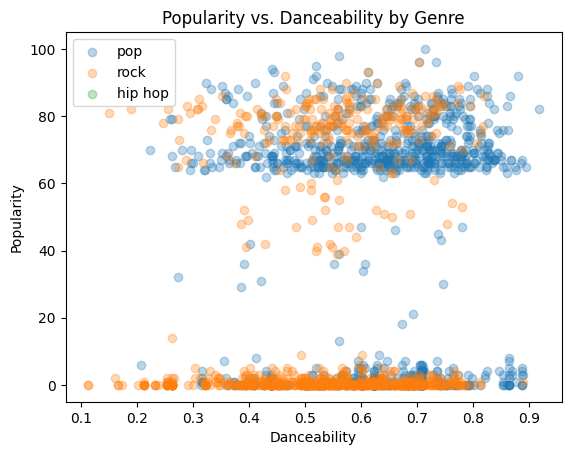

In [15]:
# maybe-TODO anything here:  correlations, statistical tests, other machine learning...
import seaborn as sns
import matplotlib.pyplot as plt

# Example: correlation between popularity and danceability by a subset of genres
subset_genres = ["pop", "rock", "hip hop"]
df_subset = df[df["track_genre"].isin(subset_genres)]

plt.figure()
for g in subset_genres:
    tmp = df_subset[df_subset["track_genre"] == g]
    plt.scatter(tmp["danceability"], tmp["popularity"], alpha=0.3, label=g)

plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.title("Popularity vs. Danceability by Genre")
plt.legend()
plt.show()

f, 2 points plus shot at lightning talk) Look over your findings from parts (a-e) and summarize anything interesting you learned about the data from doing this study.  The students with the best answers to this question (who also chose to analyze novel datasets) may be selected to give lightning talks for additional extra credit.

**TODO**

I trained a baseline Random Forest classifier to predict a song’s genre using Spotify audio features, then improved it by tuning max_depth and n_estimators. Models with a moderate max depth (around 20) and more trees (around 200) achieved higher accuracy than the baseline. Feature importance analysis showed that energy, danceability, loudness, acousticness, and valence were the most influential predictors. Less important features included key, mode, time_signature, and explicit. I also observed correlations such as higher danceability tending to align with higher popularity, and instrumentalness strongly separating classical or ambient genres from pop and rock. Overall, the model performed best when capturing intensity-based features that differentiate genres by musical “feel.”

# AI Statement (2 points)

Please put an X in the box that best matches your AI use for this homework ([X] in the markup will become a checked box).  There is no penalty for using AI, but we want to understand how you're using it.

- [ ] I did not use AI to complete this assignment.
- [ ] I didn't use AI to debug or generate code, but I did use it as a Python reference.
- [X] I didn't use AI to generate code, but I did use it to debug some code.
- [ ] I did use AI to generate some code, but not all the code for any problem.
- [ ] I used AI to solve at least one problem completely.

**When you are done, submit both your .ipynb (File->Download->Download .ipynb in Google Colab) and a PDF (File->Print->Save to PDF) to Blackboard where you found this assignment.**  (The backup PDF helps us give you points if there's a problem with your .ipynb.)